# Prediction of the Energy of Metal Nanoparticles: Data Processing (Data-Driven Reduction)

This notebook contains the results from data processing in preparation for the machine learning predictions of the energy of metal (specifically the mono-, bi-, and tri-metallic combinations of gold, palladium, and platinum) nanoparticles. The exercise is an attempt to explore the possibility of using a machine learning model to compute the energy to save computational costs.

## Outline

[Notebook Setups](#setup)

[Data Sets](#datasets)

[Monometallic Nanoparticles](#mnps)

<a id='setup'></a>
## Notebook Setups

In [95]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [96]:
# Import relevant libraries
from os import chdir, listdir
import pickle
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# from sklearnex import patch_sklearn
# patch_sklearn()
import sklearn

from natsort import natsorted
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# chdir('/scratch/q27/jt5911')
from trainEvalModels import rmNullLowVarFeats, rmHighCorrFeats

# Print package versions for reproducibility
print('Versions of imported libraries:')
print(f"  matplotlib: {mpl.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  pandas: {pd.__version__}")
print(f"  seaborn: {sns.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")

Versions of imported libraries:
  matplotlib: 3.10.9
  numpy: 2.4.4
  pandas: 3.0.2
  seaborn: 0.13.2
  scikit-learn: 1.8.0


Below are some general settings for plotting figures:

In [97]:
# Settings for figures
sns.set_theme(context='paper', style='ticks', palette='colorblind', font='sans-serif', font_scale=1, color_codes=True, rc=None)  # Options are: {paper, notebook, talk, poster}
figSize, DPI, fontSize, labelSize = (3.5, 2.5), None, 'medium', 'small'
legendSize, lineWidth, markerSize = 'x-small', 1, 3
# SMALL_SIZE, MEDIUM_SIZE, LARGE_SIZE, TITLE_SIZE = 8, 10, 12, 14
# plt.rc('font', size=LARGE_SIZE)  # controls default text sizes
# plt.rc('axes', titlesize=TITLE_SIZE)  # fontsize of the axes title
# plt.rc('axes', labelsize=LARGE_SIZE)  # fontsize of the x and y labels
# plt.rc('xtick', labelsize=LARGE_SIZE)  # fontsize of the tick labels
# plt.rc('ytick', labelsize=LARGE_SIZE)  # fontsize of the tick labels
# plt.rc('legend', fontsize=LARGE_SIZE)  # legend fontsize
# plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title
# PLOT_COLOURS = ['#212121', '#3F51B5', '#303F9F', '#FF5252', '#D32F2F']  # black, blue, deep blue, red, deep red from https://www.materialpalette.com
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['#303F9F', '#FF5252', '#D32F2F'])

Some handy global variables:

In [98]:
VAR_THRESH = 0.0  # Value other than 0.0 is difficult to decide non-arbitrarily
VERBOSE = True
DATA_DIR = '/home/DART/jonathant/Documents/iterative-archetypal-analysis/metal-nanoparticle-energy-regression/data'
FIG_DIR = '/home/DART/jonathant/Documents/iterative-archetypal-analysis/metal-nanoparticle-energy-regression/figs'
RANDOM_SEED = 42
NUM_RUNS = 10

Some handy general functions:

In [99]:
def loadCSV(csvFilePath, isMono=True, molLabels=True, ele='Au', transPerc=True):
    """
    The monometallic dataset has different naming for certain features, hence why 'isMono' needs to be specified.
    """
    featDF = pd.read_csv(csvFilePath, sep=',', header=0)

    if isMono:
        featDF = featDF.rename(columns={'N_total': 'N_atom_total', 'N_bulk': 'N_atom_bulk', 'N_surface': 'N_atom_surface', 
                                        'Avg_total': 'MM_TCN_avg', 'Avg_bulk': 'MM_BCN_avg', 'Avg_surf': 'MM_SCN_avg', 
                                        'Avg_bonds': 'BL_avg', 'Std_bonds': 'BL_std', 'Max_bonds': 'BL_max', 'Min_bonds': 'BL_min', 'N_bonds': 'BL_num',
                                        'angle_avg': 'BA1_avg', 'angle_std': 'BA1_std'}, 
                               inplace=False)
        eleSpecificFeats = [feat for feat in featDF.columns if 'CN_' in feat 
                                                            or 'BL_' in feat
                                                            or 'BA1_' in feat]
        # Rename and generate element-specific features to match bimetallic and trimetallic feature names
        eleSpecNewFeatNamesDict = {}
        for feat in eleSpecificFeats:
            eleSpecNewFeatName = f"MMM_{feat}" if 'BA1_' in feat else f"MM_{feat}"
            eleSpecNewFeatNamesDict[feat] = eleSpecNewFeatName
            eleSpecNewFeatName = f"{ele}{ele}{ele}_{feat}" if 'BA1_' in feat else f"{ele}{ele}_{feat}"
            featDF[eleSpecNewFeatName] = featDF[feat]
        featDF = featDF.rename(columns=eleSpecNewFeatNamesDict, inplace=False)
            
        # Rename q6q6 features to match bimetallic and trimetallic q6q6 feature names
        q6q6Feats = [feat for feat in featDF.columns if 'q6q6_T_' in feat or 'q6q6_B_' in feat or 'q6q6_S_' in feat]
        q6q6NewFeatNamesDict = {}
        for feat in q6q6Feats:
            q6q6NewFeatName = f"{feat[:6]}_{feat[6:]}"
            q6q6NewFeatNamesDict[feat] = q6q6NewFeatName
        featDF = featDF.rename(columns=q6q6NewFeatNamesDict, inplace=False)
    
    # Replace count features with percentages
    if transPerc:
        bulkAtomFeats = [feat for feat in featDF.columns if ('BCN' in feat and '_avg' not in feat)
                                                         or ('BGCN' in feat and '_avg' not in feat)
                                                         or 'q6q6_B_' in feat]
        surfAtomFeats = [feat for feat in featDF.columns if ('SCN' in feat and '_avg' not in feat)
                                                         or ('SGCN' in feat and '_avg' not in feat)
                                                         or ('SOCN' in feat and '_avg' not in feat)
                                                         or ('SOGCN' in feat and '_avg' not in feat)
                                                         or 'q6q6_S_' in feat 
                                                         or 'Curve' in feat
                                                         or 'S_100' in feat
                                                         or 'S_111' in feat
                                                         or 'S_110' in feat
                                                         or 'S_311' in feat]
        totAtomFeats = [feat for feat in featDF.columns if ('MM_TCN' in feat and '_avg' not in feat)
                                                        or ('TGCN' in feat and '_avg' not in feat)
                                                        or 'q6q6_T_' in feat
                                                        or 'FCC' in feat 
                                                        or 'HCP' in feat
                                                        or 'ICOS' in feat
                                                        or 'DECA' in feat]
        numBulkAtomFeat = featDF['N_atom_bulk']
        numSurfAtomFeat = featDF['N_atom_surface']
        numTotalAtomFeat = featDF['N_atom_total']
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for col in bulkAtomFeats:
                featDF[f"{col}"] = featDF[col] / numBulkAtomFeat * 100
            for col in surfAtomFeats:
                featDF[f"{col}"] = featDF[col] / numSurfAtomFeat * 100
            for col in totAtomFeats:
                featDF[f"{col}"] = featDF[col] / numTotalAtomFeat * 100
        featDF.drop(bulkAtomFeats, axis=1, inplace=True)
        featDF.drop(surfAtomFeats, axis=1, inplace=True)
        featDF.drop(totAtomFeats, axis=1, inplace=True)

    labelFeats = [feat for feat in featDF.columns if 'Surf_defects' in feat or 'Surf_micros' in feat or 'Surf_facets' in feat or '_E' in feat]
    labelDF = featDF[labelFeats]
    featDF.drop(['ID'] + labelFeats, axis=1, inplace=True)
    return featDF, labelDF

In [100]:
def loadDF(pklFilePath):
    """
    Load dataframe saved in pickle file.
    """
    with open(pklFilePath, 'rb') as f:
        featsDF = pickle.load(f)
    return featsDF

<a id='datasets'></a>
## Datasets

The datasets used here are atomic coordinates of simulated metal nanoparticles generated for studies on the impact of polydispersivity on the properties of metal nanoparticle electrocatalyst ensembles. All data sets are hosted at [CSIRO Data Access Portal](https://data.csiro.au/collection/). The links are provided below:
- [gold](https://data.csiro.au/collection/csiro:40669)
- [palladium](https://data.csiro.au/collection/csiro:40618)
- [platinum](https://data.csiro.au/collection/csiro:36491)

<a id='mnps'></a>
## Monometallic Nanoparticles

Here we process the data for a machine learning model that aims to predict the total and formation energies of a set of simulated monometallic nanoparticles (either gold, palladium, or platinum) to be trained on. 

We aim to compare the regression results of models fitted to a small training set consisting of archetypes against the results of the same models fitted to the whole training dataset.

### Data Loading

In [101]:
# Load features
MNPDF = loadDF(f"{DATA_DIR}/MNP_E_DF.pkl")
MNPDF.dropna(inplace=True)
MNPFeatsDF, MNPtotEs, MNPformEs = MNPDF.iloc[:, :-2], MNPDF.iloc[:, -2], MNPDF.iloc[:, -1]
redMNPDF = loadDF(f"{DATA_DIR}/red_MNP_DB_DF.pkl")
redMNPFeatsDF = redMNPDF.drop(['D_avg', 'Ele'], axis=1, inplace=False)

# for feat in MNPFeatsDF.columns:
#     print(feat)

### Data Processing

In [102]:
# Rearrange feature columns based on priorities to be kept (for the highly correlated feature removal step)
sortedFeats = ['T', 'time', 'tau',
               'MM_SCN_avg', 'q6q6_avg_surf', 
               'S_100', 'S_111', 'S_110', 'S_311', 
               'N_atom_surface', 'N_atom_bulk', 'Volume', 'N_atom_total', 
               'R_avg', 'R_diff', 'R_std', 'R_min', 'R_max', 'R_skew', 'R_kurt', 
               
               'MM_TCN_avg', 'MM_BCN_avg', 
               'MM_BL_avg', 'MM_BL_std', 'MM_BL_num', 'MM_BL_max', 'MM_BL_min', 
               'MMM_BA1_avg', 'MMM_BA1_std', 
               'q6q6_avg_total', 'q6q6_avg_bulk', 
                              
               'FCC', 'HCP', 'ICOS', 'DECA', 
               
               'Curve_1-10', 'Curve_11-20', 'Curve_21-30', 'Curve_31-40', 'Curve_41-50', 'Curve_51-60', 'Curve_61-70', 'Curve_71-80', 'Curve_81-90', 
               'Curve_91-100', 'Curve_101-110', 'Curve_111-120', 'Curve_121-130', 'Curve_131-140', 'Curve_141-150', 'Curve_151-160', 'Curve_161-170', 'Curve_171-180', 
               
               'MM_SCN_0', 'MM_SCN_1', 'MM_SCN_2', 'MM_SCN_3', 'MM_SCN_4', 'MM_SCN_5', 'MM_SCN_6', 'MM_SCN_7', 'MM_SCN_8', 'MM_SCN_9', 'MM_SCN_10', 
               'MM_SCN_11', 'MM_SCN_12', 'MM_SCN_13', 'MM_SCN_14', 'MM_SCN_15', 'MM_SCN_16', 'MM_SCN_17', 'MM_SCN_18', 'MM_SCN_19', 'MM_SCN_20', 
               'q6q6_S_0', 'q6q6_S_1', 'q6q6_S_2', 'q6q6_S_3', 'q6q6_S_4', 'q6q6_S_5', 'q6q6_S_6', 'q6q6_S_7', 'q6q6_S_8', 'q6q6_S_9', 'q6q6_S_10', 
               'q6q6_S_11', 'q6q6_S_12', 'q6q6_S_13', 'q6q6_S_14', 'q6q6_S_15', 'q6q6_S_16', 'q6q6_S_17', 'q6q6_S_18', 'q6q6_S_19', 'q6q6_S_20', 'q6q6_S_20+', 
               
               'MM_TCN_0', 'MM_TCN_1', 'MM_TCN_2', 'MM_TCN_3', 'MM_TCN_4', 'MM_TCN_5', 'MM_TCN_6', 'MM_TCN_7', 'MM_TCN_8', 'MM_TCN_9', 'MM_TCN_10', 
               'MM_TCN_11', 'MM_TCN_12', 'MM_TCN_13', 'MM_TCN_14', 'MM_TCN_15', 'MM_TCN_16', 'MM_TCN_17', 'MM_TCN_18', 'MM_TCN_19', 'MM_TCN_20', 
               'q6q6_T_0', 'q6q6_T_1', 'q6q6_T_2', 'q6q6_T_3', 'q6q6_T_4', 'q6q6_T_5', 'q6q6_T_6', 'q6q6_T_7', 'q6q6_T_8', 'q6q6_T_9', 'q6q6_T_10', 
               'q6q6_T_11', 'q6q6_T_12', 'q6q6_T_13', 'q6q6_T_14', 'q6q6_T_15', 'q6q6_T_16', 'q6q6_T_17', 'q6q6_T_18', 'q6q6_T_19', 'q6q6_T_20', 'q6q6_T_20+', 

               'MM_BCN_0', 'MM_BCN_1', 'MM_BCN_2', 'MM_BCN_3', 'MM_BCN_4', 'MM_BCN_5', 'MM_BCN_6', 'MM_BCN_7', 'MM_BCN_8', 'MM_BCN_9', 'MM_BCN_10', 
               'MM_BCN_11', 'MM_BCN_12', 'MM_BCN_13', 'MM_BCN_14', 'MM_BCN_15', 'MM_BCN_16', 'MM_BCN_17', 'MM_BCN_18', 'MM_BCN_19', 'MM_BCN_20', 
               'q6q6_B_0', 'q6q6_B_1', 'q6q6_B_2', 'q6q6_B_3', 'q6q6_B_4', 'q6q6_B_5', 'q6q6_B_6', 'q6q6_B_7', 'q6q6_B_8', 'q6q6_B_9', 'q6q6_B_10', 
               'q6q6_B_11', 'q6q6_B_12', 'q6q6_B_13', 'q6q6_B_14', 'q6q6_B_15', 'q6q6_B_16', 'q6q6_B_17', 'q6q6_B_18', 'q6q6_B_19', 'q6q6_B_20', 'q6q6_B_20+']
MNPFeatsDF = MNPFeatsDF[[feat for feat in sortedFeats if feat in MNPFeatsDF.columns]]

In [103]:
# Remove features with zero variance and the second feature of each highly correlated feature pairs
CORR_THRESH = 0.8

##### Whole monometallic nanoparticle dataset

In [104]:
MNPFeatsNoLowVarDF = rmNullLowVarFeats(featsDF=MNPFeatsDF, rmNull=False, varThresh=VAR_THRESH, verbose=VERBOSE)
MNPFeatsNoLowVarHighCorrDF = rmHighCorrFeats(featsDF=MNPFeatsNoLowVarDF, corrThresh=CORR_THRESH, verbose=VERBOSE)
del MNPFeatsNoLowVarDF

Removing the features with variance below 0.00...
  Original number of features: 134
  Total number of features left: 134

Removing the second feature from every pair of features with correlation above 0.80...
  Original number of features: 134
    q6q6_avg_surf MM_BL_std:    0.817
    q6q6_avg_surf MMM_BA1_std:    0.908
    q6q6_avg_surf q6q6_avg_total:    0.955
    q6q6_avg_surf q6q6_avg_bulk:    0.938
    S_100 q6q6_S_8:    0.810
    S_111 Curve_1-10:    0.887
    S_111 MM_SCN_9:    0.898
    S_111 q6q6_S_9:    0.945
    S_111 MM_TCN_9:    0.889
    S_111 q6q6_T_9:    0.872
    S_110 MM_SCN_11:    0.888
    S_110 q6q6_S_11:    0.902
    S_311 q6q6_S_10:    0.843
    N_atom_surface N_atom_bulk:    0.962
    N_atom_surface N_atom_total:    0.976
    N_atom_surface R_avg:    0.977
    N_atom_surface R_min:    0.835
    N_atom_surface R_max:    0.937
    N_atom_surface MM_BL_num:    0.972
    N_atom_surface FCC:    0.828
    N_atom_surface Curve_21-30:    0.881
    N_atom_surface MM_SCN

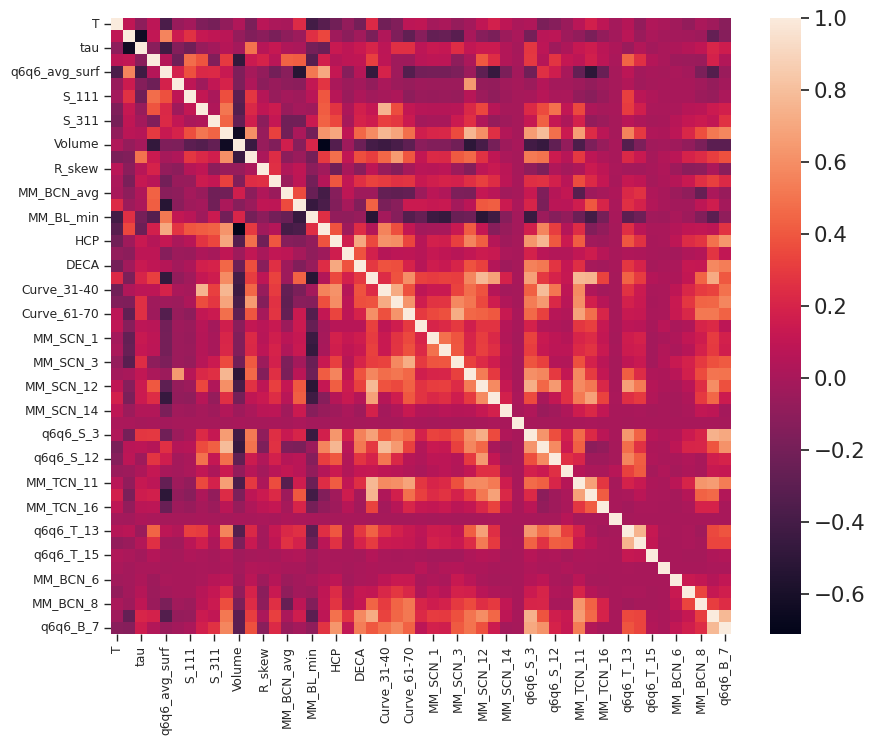

In [105]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=DPI)
sns.set(font_scale=1.4)
g = sns.heatmap(MNPFeatsNoLowVarHighCorrDF.corr(), ax=ax)
plt.savefig(f"{FIG_DIR}/corr/MNPENoC{int(CORR_THRESH * 100)}CorrHeatmap.png", bbox_inches='tight')

In [106]:
MNPDF = pd.concat([MNPFeatsNoLowVarHighCorrDF, MNPtotEs, MNPformEs], axis=1)
display(MNPDF)
display(MNPDF.describe())
del MNPFeatsNoLowVarHighCorrDF

,T,time,tau,MM_SCN_avg,q6q6_avg_surf,S_100,S_111,S_110,S_311,N_atom_surface,...,q6q6_T_14,q6q6_T_15,MM_BCN_5,MM_BCN_6,MM_BCN_7,MM_BCN_8,q6q6_B_4,q6q6_B_7,Total_E,Formation_E
0,273,1,0.000025,8.7880,2.1026,0,81,119,0,585,...,2,0,0,0,0,0,41,29,-5908.6345,343.4555
1,273,2,0.000025,8.6513,1.8783,0,65,81,1,608,...,2,0,0,0,0,0,62,40,-6035.4034,384.8166
2,273,3,0.000025,8.7303,4.3813,4,204,168,24,1272,...,21,0,0,0,0,0,129,168,-17330.1660,800.5040
3,273,4,0.000025,8.5778,5.5250,8,178,246,46,1897,...,117,0,0,0,1,0,63,112,-26937.2010,1171.7890
4,273,5,0.000025,8.5533,5.5505,18,204,269,57,2496,...,136,0,0,0,0,2,64,169,-41427.9010,1597.7390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9295,673,6,0.000250,8.0580,7.6727,40,133,116,148,1225,...,0,0,0,0,0,0,0,2,-17528.9180,1529.3920
9296,673,7,0.000250,8.0279,7.5641,44,133,90,151,1326,...,0,0,0,0,0,0,1,0,-19609.9810,1681.3190
9297,673,8,0.000250,8.0397,7.4645,45,156,107,142,1436,...,0,0,0,0,0,0,1,8,-21799.8280,1851.4020
9298,673,9,0.000250,8.0899,7.3380,30,177,121,151,1568,...,0,0,0,0,0,1,1,4,-23852.5130,2008.6270


,T,time,tau,MM_SCN_avg,q6q6_avg_surf,S_100,S_111,S_110,S_311,N_atom_surface,...,q6q6_T_14,q6q6_T_15,MM_BCN_5,MM_BCN_6,MM_BCN_7,MM_BCN_8,q6q6_B_4,q6q6_B_7,Total_E,Formation_E
count,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,...,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000,9299.000000
mean,606.293903,8.112700,0.000058,8.379558,5.910015,35.688999,198.903968,124.666738,45.544252,978.915045,...,5.470803,0.001506,0.000323,0.002151,0.019464,0.235617,18.417464,29.406388,-14051.030608,1046.789443
std,215.327942,2.896878,0.000082,0.209930,2.473065,112.555079,275.100475,160.815650,90.867010,758.684500,...,22.639047,0.038774,0.017960,0.046329,0.166408,1.007755,30.925965,59.609328,16068.446406,951.508668
min,273.000000,1.000000,0.000000,7.454500,0.221600,0.000000,0.000000,0.000000,0.000000,92.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-87121.603000,86.063950
25%,423.000000,6.000000,0.000000,8.246300,5.034800,0.000000,58.000000,48.000000,6.000000,432.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-17646.379000,398.874600
50%,623.000000,10.000000,0.000000,8.403600,6.680300,7.000000,130.000000,81.000000,19.000000,666.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,4.000000,-7032.537400,675.301400
75%,723.000000,10.000000,0.000125,8.530950,7.828350,28.000000,230.000000,149.000000,50.000000,1353.500000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,33.000000,-3865.397100,1363.468000
max,973.000000,10.000000,0.000250,8.923300,8.833300,1794.000000,2661.000000,2414.000000,1607.000000,3200.000000,...,423.000000,1.000000,1.000000,1.000000,4.000000,17.000000,312.000000,567.000000,-441.765950,5161.302000


In [107]:
with open(f"{DATA_DIR}/processed/processedMNPEdataNoC{int(CORR_THRESH * 100)}.pkl", 'wb') as f:
    pickle.dump(MNPDF, f)

##### Reduced monometallic nanoparticle dataset, consisting of most archetypal samples

In [108]:
redMNPFeatsNoLowVarDF = rmNullLowVarFeats(featsDF=redMNPFeatsDF, rmNull=False, varThresh=VAR_THRESH, verbose=VERBOSE)
redMNPFeatsNoLowVarHighCorrDF = rmHighCorrFeats(featsDF=redMNPFeatsNoLowVarDF, corrThresh=CORR_THRESH, verbose=VERBOSE)
del redMNPFeatsNoLowVarDF

Removing the features with variance below 0.00...
  Original number of features: 182
    Curve_81-90:    0.000
    Curve_91-100:    0.000
    Curve_101-110:    0.000
    Curve_111-120:    0.000
    Curve_121-130:    0.000
    Curve_131-140:    0.000
    Curve_141-150:    0.000
    Curve_151-160:    0.000
    Curve_161-170:    0.000
    Curve_171-180:    0.000
    MM_TCN_0:    0.000
    MM_TCN_18:    0.000
    MM_TCN_19:    0.000
    MM_TCN_20:    0.000
    MM_BCN_0:    0.000
    MM_BCN_1:    0.000
    MM_BCN_2:    0.000
    MM_BCN_3:    0.000
    MM_BCN_4:    0.000
    MM_BCN_18:    0.000
    MM_BCN_19:    0.000
    MM_BCN_20:    0.000
    MM_SCN_0:    0.000
    MM_SCN_16:    0.000
    MM_SCN_17:    0.000
    MM_SCN_18:    0.000
    MM_SCN_19:    0.000
    MM_SCN_20:    0.000
    q6q6_T_16:    0.000
    q6q6_T_17:    0.000
    q6q6_T_18:    0.000
    q6q6_T_19:    0.000
    q6q6_T_20:    0.000
    q6q6_T_20+:    0.000
    q6q6_B_16:    0.000
    q6q6_B_17:    0.000
    q6q6_B_18:    0.

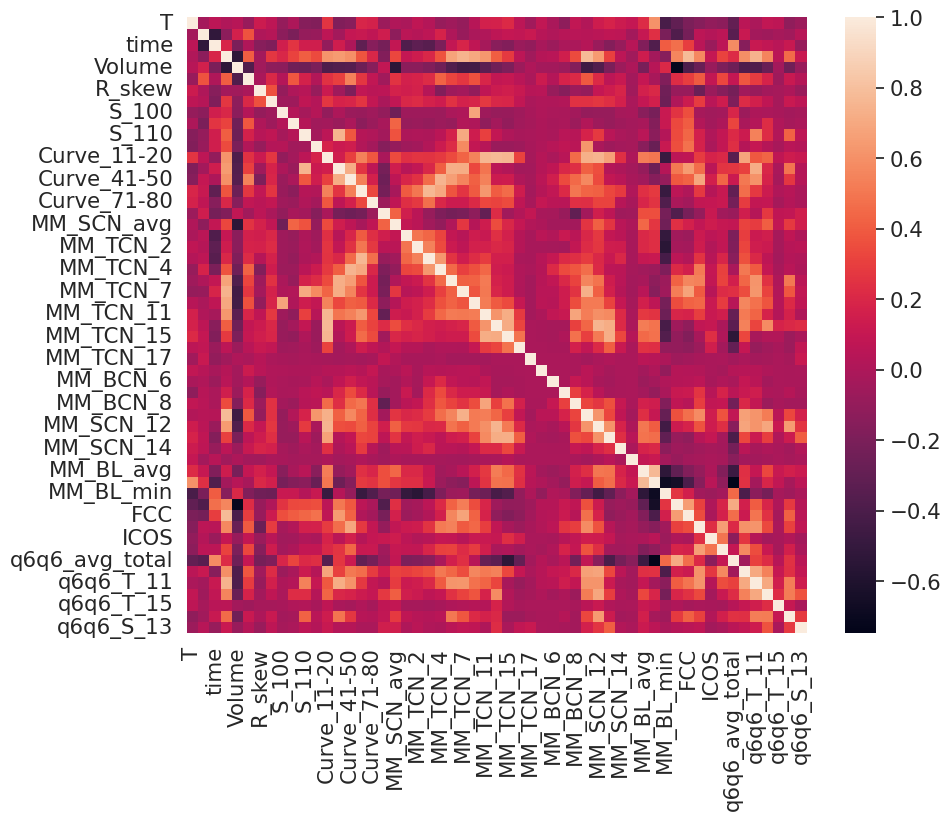

In [109]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=DPI)
sns.set(font_scale=1.4)
g = sns.heatmap(redMNPFeatsNoLowVarHighCorrDF.corr(), ax=ax)
plt.savefig(f"{FIG_DIR}/corr/redMNPENoC{int(CORR_THRESH * 100)}CorrHeatmap.png", bbox_inches='tight')

In [110]:
redMNPDF = pd.concat([redMNPFeatsNoLowVarHighCorrDF, MNPtotEs.loc[redMNPFeatsDF.index], MNPformEs.loc[redMNPFeatsDF.index]], axis=1)
display(redMNPDF)
display(redMNPDF.describe())
del redMNPFeatsNoLowVarHighCorrDF

,T,tau,time,N_atom_total,Volume,R_diff,R_skew,R_kurt,S_100,S_111,...,DECA,q6q6_avg_total,q6q6_T_4,q6q6_T_11,q6q6_T_13,q6q6_T_15,q6q6_S_12,q6q6_S_13,Total_E,Formation_E
3008,823,0.000025,9,14002,0.000004,0.72084,0.01059,0.02071,7,100,...,3,0.6495,193,0,0,0,0,0,-51224.8960,3522.9240
3908,973,0.000025,9,14057,0.000004,0.83997,-0.01472,-0.01987,5,49,...,0,0.4802,95,0,0,0,0,0,-50922.7920,4040.0780
8006,303,0.000025,7,15135,0.000005,0.76829,0.02403,0.05243,42,187,...,24,9.7402,281,1070,47,0,1,0,-83537.5240,3791.4260
4909,373,0.000025,10,15900,0.000004,1.36468,-0.05189,0.78587,51,210,...,225,10.1693,329,874,543,0,11,0,-59198.9600,2970.0400
8436,473,0.000100,7,9504,0.000008,1.92710,-0.04534,-0.04108,52,165,...,55,10.0636,135,554,3,0,0,0,-51520.6560,3317.4240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9013,673,0.000000,10,2172,0.000033,0.51118,0.06846,0.03426,0,117,...,0,10.6418,6,146,2,0,1,0,-11498.2140,1034.2260
185,303,0.000225,6,1550,0.000038,1.07566,0.02520,-0.05512,1,112,...,0,9.3148,46,115,185,0,7,0,-5718.0775,342.4225
4534,323,0.000000,10,1721,0.000040,0.36577,0.01002,-0.08316,24,168,...,0,10.6775,0,143,1,0,0,0,-6179.6360,549.4740
7711,923,0.000000,10,4605,0.000015,0.46826,0.00518,-0.05744,45,169,...,0,10.7053,45,200,196,0,6,0,-16039.4320,1966.1180


,T,tau,time,N_atom_total,Volume,R_diff,R_skew,R_kurt,S_100,S_111,...,DECA,q6q6_avg_total,q6q6_T_4,q6q6_T_11,q6q6_T_13,q6q6_T_15,q6q6_S_12,q6q6_S_13,Total_E,Formation_E
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,569.920000,0.000052,7.972000,4889.652000,0.000050,1.106929,0.028977,0.073604,45.236000,235.256000,...,13.592000,8.335940,76.584000,227.820000,180.552000,0.008000,2.504000,0.080000,-18932.042292,1285.035348
std,241.854684,0.000081,3.079146,4910.078393,0.000068,0.785930,0.071834,0.357318,160.923753,376.434475,...,35.264485,3.424603,94.646218,335.628134,381.945978,0.089263,5.859293,0.492514,19481.634695,1164.233649
min,273.000000,0.000000,1.000000,158.000000,0.000004,0.206120,-0.235900,-0.131140,0.000000,2.000000,...,0.000000,0.389800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-83537.524000,90.797010
25%,323.000000,0.000000,6.250000,1134.500000,0.000007,0.501370,-0.006457,-0.047395,0.000000,48.000000,...,0.000000,7.934850,9.000000,3.000000,2.000000,0.000000,0.000000,0.000000,-36826.949500,390.955275
50%,523.000000,0.000000,10.000000,2214.000000,0.000029,0.826760,0.023465,-0.016485,5.000000,149.000000,...,0.000000,9.890800,31.000000,68.500000,28.500000,0.000000,0.000000,0.000000,-8649.575800,757.586500
75%,773.000000,0.000075,10.000000,9340.250000,0.000057,1.509425,0.060625,0.041165,25.000000,260.250000,...,8.000000,10.561050,126.250000,274.000000,145.750000,0.000000,2.000000,0.000000,-4041.927450,1978.444250
max,973.000000,0.000250,10.000000,16148.000000,0.000431,4.089730,0.372880,3.410650,1763.000000,2584.000000,...,225.000000,11.375700,447.000000,1460.000000,2345.000000,1.000000,49.000000,5.000000,-503.392130,5161.302000


In [111]:
with open(f"{DATA_DIR}/processed/processedRedMNPEdataNoC{int(CORR_THRESH * 100)}.pkl", 'wb') as f:
    pickle.dump(redMNPDF, f)

##### Reduced monometallic nanoparticle dataset, with equal number of sample as the archetypal dataset, obtained via random sampling

Removing the features with variance below 0.00...
  Original number of features: 134
    MM_SCN_15:    0.000
    MM_TCN_17:    0.000
    q6q6_T_15:    0.000
    MM_BCN_5:    0.000
    MM_BCN_6:    0.000
    MM_BCN_17:    0.000
    q6q6_B_15:    0.000
  Total number of features left: 127

Removing the second feature from every pair of features with correlation above 0.80...
  Original number of features: 127
    q6q6_avg_surf MMM_BA1_std:    0.893
    q6q6_avg_surf q6q6_avg_total:    0.945
    q6q6_avg_surf q6q6_avg_bulk:    0.924
    S_111 Curve_1-10:    0.931
    S_111 MM_SCN_9:    0.902
    S_111 q6q6_S_9:    0.951
    S_111 MM_TCN_9:    0.894
    S_111 q6q6_T_9:    0.860
    S_110 MM_SCN_11:    0.904
    S_110 q6q6_S_11:    0.944
    S_311 q6q6_S_10:    0.852
    N_atom_surface N_atom_bulk:    0.963
    N_atom_surface N_atom_total:    0.975
    N_atom_surface R_avg:    0.979
    N_atom_surface R_min:    0.836
    N_atom_surface R_max:    0.940
    N_atom_surface MM_BL_num:    0.972


<Figure size 640x480 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

...

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

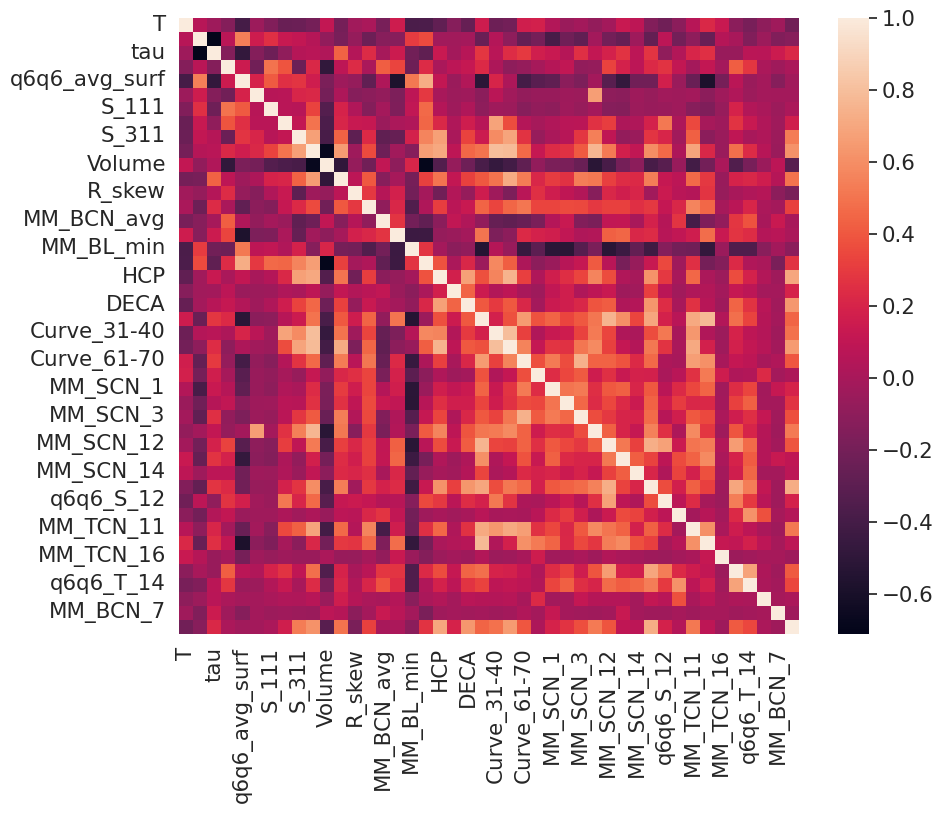

In [112]:
numSamples = redMNPFeatsDF.shape[0]
for i in range(NUM_RUNS):
    # Feature selection
    featsDF = MNPFeatsDF.sample(n=numSamples, random_state=RANDOM_SEED + i)
    noLowVarDF = rmNullLowVarFeats(featsDF=featsDF, rmNull=False, varThresh=VAR_THRESH, verbose=VERBOSE)
    noLowVarHighCorrDF = rmHighCorrFeats(featsDF=noLowVarDF, corrThresh=CORR_THRESH, verbose=VERBOSE)
    del noLowVarDF
    
    plt.clf()
    fig, ax = plt.subplots(figsize=(10, 8), dpi=DPI)
    sns.set(font_scale=1.4)
    g = sns.heatmap(noLowVarHighCorrDF.corr(), ax=ax)
    plt.savefig(f"{FIG_DIR}/corr/randRedMNPENoC{int(CORR_THRESH * 100)}run{i+1}CorrHeatmap.png", bbox_inches='tight')

    # Merge labels with features
    MNPDF = pd.concat([noLowVarHighCorrDF, MNPtotEs.loc[featsDF.index], MNPformEs.loc[featsDF.index]], axis=1)
    del noLowVarHighCorrDF

    # Data storage
    with open(f"{DATA_DIR}/processed/processedRandRedMNPdataNoC{int(CORR_THRESH * 100)}run{i+1}.pkl", 'wb') as f:
        pickle.dump(MNPDF, f)